<a href="https://colab.research.google.com/github/ayyucedemirbas/quality_control/blob/main/nakatake_QC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scAnalysis

In [2]:
import os
import warnings
import numpy as np
import pandas as pd

from scAnalysis import (
    sc_io,
    preprocessing,
    quality_control,
    cell_cycle,
    dimensionality,
    visualization
)

warnings.filterwarnings("ignore")

In [3]:
os.makedirs("output_qc_report_nakatake", exist_ok=True)

In [4]:
local_h5ad_path = "/content/drive/MyDrive/resources/grn_benchmark/inference_data/nakatake_rna.h5ad"
data = sc_io.read_h5ad(local_h5ad_path)
data.var.index = sc_io._make_unique(data.var.index.values)

print(f"Nakatake dataset: {data.n_obs} samples (bulk) and {data.n_vars} genes.")


preprocessing.calculate_qc_metrics(data, qc_vars=["MT-", "mt-"])

IO: Reading H5AD from '/content/drive/MyDrive/resources/grn_benchmark/inference_data/nakatake_rna.h5ad' ...
IO: Loaded 460 cells × 25,090 genes.
Nakatake dataset: 460 samples (bulk) and 25090 genes.


Saved → output_qc_report_nakatake/1_QC_Violins_Before_Filter.png


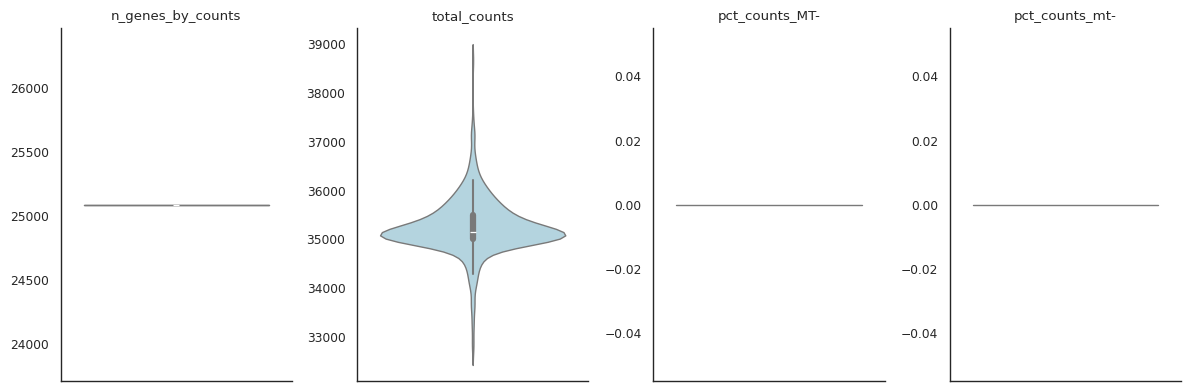

In [5]:
visualization.plot_qc_violin(
    data,
    save="output_qc_report_nakatake/1_QC_Violins_Before_Filter.png"
)

In [6]:
data = preprocessing.filter_genes(data, min_cells=3)

filter_genes: keeping 25,090 / 25,090 genes.


Saved → output_qc_report_nakatake/1_QC_Violins_Before_Filter.png


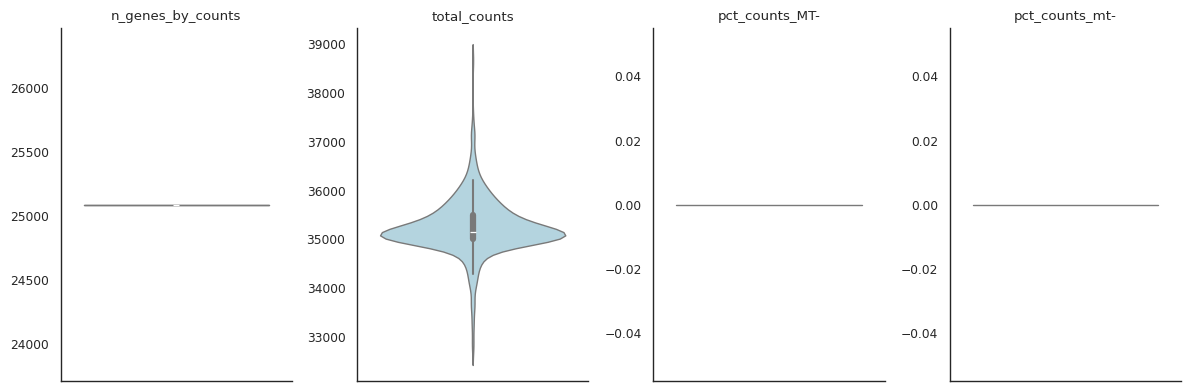

In [7]:
visualization.plot_qc_violin(
    data,
    save="output_qc_report_nakatake/1_QC_Violins_Before_Filter.png"
)

In [8]:
data = preprocessing.filter_genes(data, min_cells=3)

preprocessing.normalize_total(data, target_sum=1e4)
preprocessing.log1p(data)

filter_genes: keeping 25,090 / 25,090 genes.


In [9]:
print(f"Total samples: {data.n_obs}")
print("Detected Doublets: N/A (Bulk RNA-seq data does not contain single-cell doublets)")
print(f"Mean Genes per Sample: {data.obs['n_genes_by_counts'].mean():.0f}")
if 'pct_counts_MT-' in data.obs.columns:
    print(f"Mean MT Percentage: {data.obs['pct_counts_MT-'].mean():.2f}%")

Total samples: 460
Detected Doublets: N/A (Bulk RNA-seq data does not contain single-cell doublets)
Mean Genes per Sample: 25090
Mean MT Percentage: 0.00%


In [10]:
cell_cycle.score_cell_cycle(data, organism="human")
preprocessing.highly_variable_genes(data, n_top_genes=2000)

HVG: identified 2,000 highly variable genes.


In [11]:
hvg_mask = data.var["highly_variable"].values
data_hvg = data[:, hvg_mask].copy()

In [12]:
data_before = data_hvg.copy()

preprocessing.scale(data_before, max_value=10)
dimensionality.run_pca(data_before, n_components=30)
dimensionality.neighbors(data_before, n_neighbors=15, n_pcs=30)
dimensionality.run_umap(data_before, min_dist=0.3)

PCA: using 2,000 HVGs.
PCA: computed 30 components (65.7% variance explained).
Neighbors: k=15, metric='euclidean' …
Neighbors: graph built (460 cells).
UMAP: min_dist=0.3, n_components=2 …


SingleCellDataset object with n_obs × n_vars = 460 × 2000
    obs: perturbation, is_control, perturbation_type, n_genes, n_genes_by_counts, total_counts, pct_counts_MT-, pct_counts_mt-, S_score, G2M_score, phase
    var: n_cells, means, dispersions, dispersions_norm, highly_variable
    uns: encoding-type, encoding-version, data_reference, data_url, dataset_description, dataset_id, dataset_name, dataset_organism, dataset_summary, normalization_id, pca, neighbors
    obsm: X_pca, X_umap
    varm: PCs
    Memory (X): 7.02 MB

In [13]:
visualization.plot_umap(
    data_before,
    color="phase",
    title="Nakatake UMAP Before CC Regression",
    save="output_qc_report_nakatake/2_UMAP_Before_CC_Regression.png"
)

Saved → output_qc_report_nakatake/2_UMAP_Before_CC_Regression.png


<Axes: title={'center': 'Nakatake UMAP Before CC Regression'}, xlabel='X_umap 1', ylabel='X_umap 2'>

In [14]:
del data_before

In [15]:
cell_cycle.regress_out_cell_cycle(data_hvg, difference_only=False)

SingleCellDataset object with n_obs × n_vars = 460 × 2000
    obs: perturbation, is_control, perturbation_type, n_genes, n_genes_by_counts, total_counts, pct_counts_MT-, pct_counts_mt-, S_score, G2M_score, phase
    var: n_cells, means, dispersions, dispersions_norm, highly_variable
    uns: encoding-type, encoding-version, data_reference, data_url, dataset_description, dataset_id, dataset_name, dataset_organism, dataset_summary, normalization_id
    Memory (X): 7.02 MB

In [16]:
preprocessing.scale(data_hvg, max_value=10)
dimensionality.run_pca(data_hvg, n_components=30)
dimensionality.neighbors(data_hvg, n_neighbors=15, n_pcs=30)
dimensionality.run_umap(data_hvg, min_dist=0.3)

PCA: using 2,000 HVGs.
PCA: computed 30 components (64.1% variance explained).
Neighbors: k=15, metric='euclidean' …
Neighbors: graph built (460 cells).
UMAP: min_dist=0.3, n_components=2 …


SingleCellDataset object with n_obs × n_vars = 460 × 2000
    obs: perturbation, is_control, perturbation_type, n_genes, n_genes_by_counts, total_counts, pct_counts_MT-, pct_counts_mt-, S_score, G2M_score, phase
    var: n_cells, means, dispersions, dispersions_norm, highly_variable
    uns: encoding-type, encoding-version, data_reference, data_url, dataset_description, dataset_id, dataset_name, dataset_organism, dataset_summary, normalization_id, pca, neighbors
    obsm: X_pca, X_umap
    varm: PCs
    Memory (X): 7.02 MB

In [17]:
visualization.plot_umap(
    data_hvg,
    color="phase",
    title="Nakatake UMAP After CC Regression",
    save="output_qc_report_nakatake/3_UMAP_After_CC_Regression.png"
)

Saved → output_qc_report_nakatake/3_UMAP_After_CC_Regression.png


<Axes: title={'center': 'Nakatake UMAP After CC Regression'}, xlabel='X_umap 1', ylabel='X_umap 2'>

In [18]:
print("Cell Cycle Distribution:")
print(data_hvg.obs['phase'].value_counts().to_string())

Cell Cycle Distribution:
phase
S      262
G1     133
G2M      0
